<a href="https://colab.research.google.com/github/Coder-Said/Proyecto_IA/blob/main/Modelo/Diagnostico_AST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diagnóstico de fallas mecánicas por sonido (AST + clasificador)

**Cómo funciona:** el modelo AST (preentrenado con millones de sonidos generales) convierte cada audio en un vector de 768 números. Sobre esos vectores se entrena un clasificador con **tus** etiquetas (estado/condición). Las fallas las aprende tu dataset, no AST.

**Antes de empezar:** Entorno de ejecución → Cambiar tipo de entorno → **GPU (T4)**. Si Colab se reinicia, vuelve a ejecutar todo: los vectores quedan guardados en Drive y la segunda vez es mucho más rápido.

**Orden:** ejecuta las celdas de arriba a abajo. La última te pide subir un audio para diagnosticarlo.

In [1]:
# 1. Instalación, imports y configuración
%pip install -q transformers

import os, random, warnings, joblib
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torchaudio
import librosa
import librosa.display
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import Audio, display

from transformers import ASTFeatureExtractor, ASTModel
from transformers.utils import logging as hf_logging

from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score

hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["PYTHONWARNINGS"] = "ignore"   # también silencia los procesos paralelos de la búsqueda

# Montar Drive (solo en Colab)
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass

RUTA_DATASET = Path("/content/drive/MyDrive/Car_Dataset/car diagnostics dataset")
RUTA_CACHE = RUTA_DATASET.parent / "cache_modelo_audio"       # vectores y modelo guardados aquí
RUTA_CACHE.mkdir(parents=True, exist_ok=True)
RUTA_EMBEDDINGS = RUTA_CACHE / "embeddings_ast.npz"
RUTA_MODELO = RUTA_CACHE / "modelo_diagnostico.joblib"

EXTENSIONES = {".wav", ".mp3", ".flac", ".ogg"}
NOMBRE_AST = "MIT/ast-finetuned-audioset-10-10-0.4593"
SR, MAX_SEG, SEED = 16000, 10, 42      # AST usa audio a 16 kHz y hasta ~10 s
CONFIANZA_MINIMA = 0.60                # por debajo, el resultado no se considera diagnóstico
MARGEN_MINIMO = 0.15                   # diferencia mínima entre la 1ª y la 2ª opción

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if device.type == "cpu":
    print("Aviso: sin GPU el cálculo de vectores será lento. Activa la GPU en el tipo de entorno.")

Mounted at /content/drive
Dispositivo: cuda


In [2]:
# 2. Nombres legibles de cada clase (la clave es la ruta de carpetas del dataset)
DIAGNOSTICOS = {
    "Frenos/normal_brakes": "Frenos en buen estado",
    "Frenos/worn_out_brakes": "Frenos desgastados",
    "idle state/normal_engine_idle": "Motor normal en ralentí",
    "idle state/low_oil": "Nivel bajo de aceite",
    "idle state/power_steering": "Falla en la dirección hidráulica",
    "idle state/serpentine_belt": "Falla en la correa serpentina",
    "idle state/combined/no oil_serpentine belt": "Combinada: poco aceite + correa serpentina",
    "idle state/combined/power steering combined_serpentine belt": "Combinada: dirección hidráulica + correa serpentina",
    "idle state/combined/power steering combined_no oil_serpentine belt": "Combinada: dirección hidráulica + poco aceite + correa serpentina",
    "startup state/normal_engine_startup": "Arranque normal",
    "startup state/bad_ignition": "Encendido defectuoso",
    "startup state/dead_battery": "Batería descargada",
}

Total de audios: 1248 | clases: 12


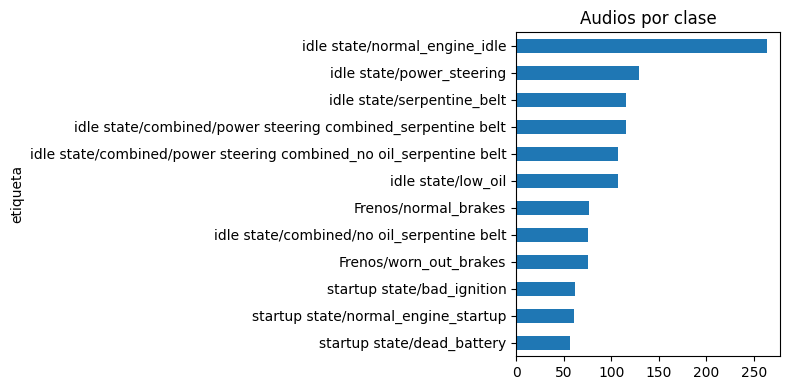

In [3]:
# 3. Catálogo de audios (la etiqueta es la carpeta que contiene el audio)
archivos = sorted(p for p in RUTA_DATASET.rglob("*") if p.suffix.lower() in EXTENSIONES)
if not archivos:
    raise FileNotFoundError(f"No se encontraron audios en {RUTA_DATASET}. Verifica la ruta y que Drive esté montado.")

def etiqueta_de(p):
    partes = p.relative_to(RUTA_DATASET).parts
    return "/".join(partes[:-1]) if len(partes) > 2 else None

df = pd.DataFrame({"ruta": [str(p) for p in archivos], "etiqueta": [etiqueta_de(p) for p in archivos]})
n_sin = df["etiqueta"].isna().sum()
if n_sin:
    print(f"Aviso: {n_sin} audios sin carpeta de condición, se omiten.")
df = df.dropna().reset_index(drop=True)

conteo = df["etiqueta"].value_counts()
print(f"Total de audios: {len(df)} | clases: {len(conteo)}")
desconocidas = set(conteo.index) - set(DIAGNOSTICOS)
if desconocidas:
    print("Clases sin nombre en DIAGNOSTICOS (se mostrará la ruta):", desconocidas)

conteo.sort_values().plot.barh(figsize=(8, 4), title="Audios por clase")
plt.tight_layout(); plt.show()

In [4]:
# 4. Modelo AST y funciones para convertir audio en vectores
extractor = ASTFeatureExtractor.from_pretrained(NOMBRE_AST)
ast_model = ASTModel.from_pretrained(NOMBRE_AST).to(device).eval()
DIM = ast_model.config.hidden_size


def cargar(ruta, max_seg=MAX_SEG):
    # Carga mono a 16 kHz; usa librosa como respaldo si torchaudio no puede leer el formato
    try:
        wav, sr = torchaudio.load(ruta)
        wav = wav.mean(0)
        if sr != SR:
            wav = torchaudio.functional.resample(wav, sr, SR)
        wav = wav.numpy()
    except Exception:
        wav, _ = librosa.load(ruta, sr=SR, mono=True)
    wav = wav[: SR * max_seg].astype(np.float32)
    if len(wav) == 0:
        raise ValueError("audio vacío")
    pico = np.abs(wav).max()
    return wav / pico if pico > 0 else wav


@torch.no_grad()
def _vectores(ondas):
    entrada = extractor(ondas, sampling_rate=SR, return_tensors="pt").to(device)
    return ast_model(**entrada).pooler_output.float().cpu().numpy()


def embeddings(rutas, lote=16):
    # Los audios que fallan quedan como NaN y se descartan después
    salida = np.full((len(rutas), DIM), np.nan, dtype=np.float32)
    for i in tqdm(range(0, len(rutas), lote), desc="Vectores AST"):
        idx, ondas = [], []
        for j, r in enumerate(rutas[i:i + lote]):
            try:
                ondas.append(cargar(r)); idx.append(i + j)
            except Exception as e:
                print(f"Omitido {Path(r).name}: {e}")
        if ondas:
            salida[idx] = _vectores(ondas)
    return salida


def embeddings_con_cache(rutas, archivo):
    if archivo.exists():
        datos = np.load(archivo)
        if datos["rutas"].tolist() == rutas:
            print("Vectores cargados desde la caché de Drive")
            return datos["X"]
    X = embeddings(rutas)
    np.savez(archivo, rutas=np.array(rutas), X=X)
    return X

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [5]:
# 5. Vectores de todo el dataset + división entrenamiento / validación
X_all = embeddings_con_cache(df["ruta"].tolist(), RUTA_EMBEDDINGS)

validos = ~np.isnan(X_all).any(axis=1)
if not validos.all():
    print(f"Se omiten {(~validos).sum()} audios que no se pudieron procesar")
    df, X_all = df[validos].reset_index(drop=True), X_all[validos]

clases = sorted(df["etiqueta"].unique())
label2id = {c: i for i, c in enumerate(clases)}
id2label = {i: c for c, i in label2id.items()}
y_all = df["etiqueta"].map(label2id).values

idx_tr, idx_va = train_test_split(np.arange(len(df)), test_size=0.2, stratify=y_all, random_state=SEED)
X_tr, y_tr, X_va, y_va = X_all[idx_tr], y_all[idx_tr], X_all[idx_va], y_all[idx_va]
val_df = df.iloc[idx_va]
print(f"Entrenamiento: {len(idx_tr)} audios | Validación: {len(idx_va)} audios | Vectores: {X_all.shape}")

Vectores AST:   0%|          | 0/78 [00:00<?, ?it/s]

Entrenamiento: 998 audios | Validación: 250 audios | Vectores: (1248, 768)


In [6]:
# 6. Búsqueda del mejor clasificador (validación cruzada solo sobre entrenamiento)
pipe = Pipeline([("escala", StandardScaler()), ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))])
espacio = [
    {"clf": [LogisticRegression(max_iter=3000, class_weight="balanced")], "clf__C": [0.01, 0.1, 1, 10]},
    {"clf": [SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED)], "clf__C": [1, 10, 100]},
]
busqueda = GridSearchCV(pipe, espacio, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                        scoring="f1_macro", n_jobs=-1, verbose=1)
busqueda.fit(X_tr, y_tr)

clf = busqueda.best_estimator_      # entrenado solo con el conjunto de entrenamiento
print("Mejor configuración:", busqueda.best_params_)
print(f"F1 macro en validación cruzada: {busqueda.best_score_:.3f}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Mejor configuración: {'clf': LogisticRegression(class_weight='balanced', max_iter=3000), 'clf__C': 0.01}
F1 macro en validación cruzada: 0.733


                                                                    precision    recall  f1-score   support

                                              Frenos/normal_brakes      0.800     1.000     0.889        16
                                            Frenos/worn_out_brakes      1.000     0.867     0.929        15
                        idle state/combined/no oil_serpentine belt      0.417     0.333     0.370        15
idle state/combined/power steering combined_no oil_serpentine belt      0.455     0.455     0.455        22
       idle state/combined/power steering combined_serpentine belt      0.591     0.565     0.578        23
                                                idle state/low_oil      0.789     0.682     0.732        22
                                     idle state/normal_engine_idle      0.911     0.962     0.936        53
                                         idle state/power_steering      0.759     0.846     0.800        26
                           

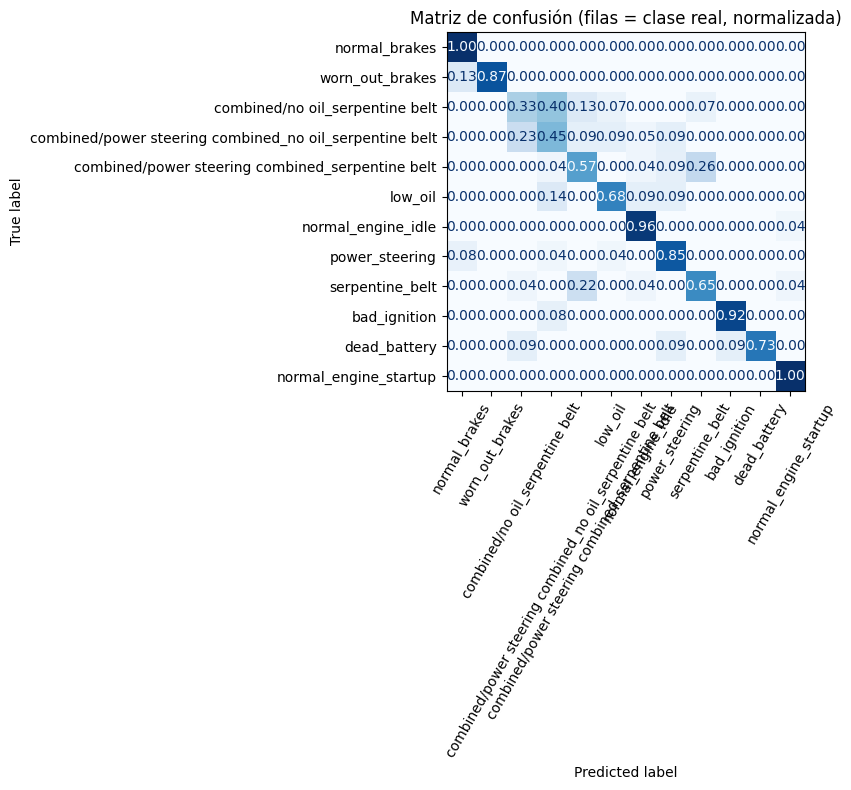

Umbral de confianza -> % de audios que cubre y su accuracy
  >= 0.0: cobertura 100.0% | accuracy  76.4%
  >= 0.4: cobertura  89.2% | accuracy  81.2%
  >= 0.5: cobertura  81.2% | accuracy  86.2%
  >= 0.6: cobertura  68.4% | accuracy  90.1%
  >= 0.7: cobertura  56.4% | accuracy  95.0%
  >= 0.8: cobertura  44.4% | accuracy  98.2%
  >= 0.9: cobertura  27.2% | accuracy 100.0%


In [7]:
# 7. Evaluación en el conjunto de validación
etiquetas = list(range(len(clases)))
cortas = [c.split("/", 1)[1] for c in clases]
probs_va = clf.predict_proba(X_va)
pred_va = clf.classes_[probs_va.argmax(1)]

print(classification_report(y_va, pred_va, labels=etiquetas, target_names=clases, digits=3, zero_division=0))
print(f"Accuracy: {(pred_va == y_va).mean()*100:.1f}% | F1 macro: {f1_score(y_va, pred_va, average='macro')*100:.1f}%\n")

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(y_va, pred_va, labels=etiquetas, display_labels=cortas, normalize="true",
                                        xticks_rotation=60, cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
ax.set_title("Matriz de confusión (filas = clase real, normalizada)")
plt.tight_layout(); plt.show()

# ¿Cuánto se puede confiar según el porcentaje que da el modelo?
conf = probs_va.max(1)
print("Umbral de confianza -> % de audios que cubre y su accuracy")
for umbral in (0.0, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9):
    m = conf >= umbral
    if m.any():
        print(f"  >= {umbral:.1f}: cobertura {m.mean()*100:5.1f}% | accuracy {(pred_va[m] == y_va[m]).mean()*100:5.1f}%")

In [8]:
# 8. Modelo final: se reentrena con TODOS los audios y se guarda en Drive
modelo_final = clone(clf).fit(X_all, y_all)
joblib.dump({"modelo": modelo_final, "id2label": id2label, "nombre_ast": NOMBRE_AST}, RUTA_MODELO)
print(f"Modelo guardado en: {RUTA_MODELO}")
# Las métricas de arriba corresponden al modelo `clf` (sin los audios de validación).
# El modelo final tiene más datos, pero ya no se puede medir con esos mismos audios.

Modelo guardado en: /content/drive/MyDrive/Car_Dataset/cache_modelo_audio/modelo_diagnostico.joblib


In [9]:
# 9. Funciones de diagnóstico
def diagnosticar(ruta, top_k=3, graficar=True):
    wav = cargar(ruta)
    probs = modelo_final.predict_proba(_vectores([wav]))[0]
    ids = modelo_final.classes_
    orden = probs.argsort()[::-1][:top_k]
    top = [(id2label[ids[i]], probs[i]) for i in orden]
    mejor, p1 = top[0]
    p2 = top[1][1] if len(top) > 1 else 0.0
    dur = len(wav) / SR

    print(f"Audio: {Path(ruta).name} | duración analizada: {dur:.1f} s\n")
    for clase, p in top:
        print(f"  {p*100:5.1f}%  {DIAGNOSTICOS.get(clase, clase)}   [{clase}]")
    print()
    if dur < 3:
        print("Aviso: el audio dura menos de 3 s; el resultado puede ser menos fiable.")
    if p1 < CONFIANZA_MINIMA:
        print("Confianza baja: el sonido no se parece claramente a ninguna clase conocida. No es un diagnóstico.")
    elif p1 - p2 < MARGEN_MINIMO:
        print("Resultado ambiguo: las dos primeras opciones tienen probabilidades parecidas.")
    elif "normal" in mejor:
        print("Sin falla aparente según el modelo.")
    else:
        print("Posible falla detectada. Confírmala con una revisión mecánica.")

    if graficar:
        fig, ax = plt.subplots(3, 1, figsize=(9, 9))
        librosa.display.waveshow(wav, sr=SR, ax=ax[0]); ax[0].set_title("Forma de onda")
        S = librosa.power_to_db(librosa.feature.melspectrogram(y=wav, sr=SR, n_mels=64), ref=np.max)
        librosa.display.specshow(S, sr=SR, x_axis="time", y_axis="mel", ax=ax[1]); ax[1].set_title("Espectrograma Mel")
        nombres = [DIAGNOSTICOS.get(c, c) for c, _ in top][::-1]
        ax[2].barh(nombres, [p for _, p in top][::-1]); ax[2].set_xlim(0, 1)
        ax[2].axvline(CONFIANZA_MINIMA, color="gray", linestyle="--"); ax[2].set_title("Probabilidad (línea = confianza mínima)")
        plt.tight_layout(); plt.show()
        display(Audio(wav, rate=SR))


def probar_validacion(n=8, etiqueta=None, semilla=None):
    # Compara etiqueta real vs predicción con audios de validación (usa `clf`, que no los vio al entrenar)
    sub = val_df if etiqueta is None else val_df[val_df["etiqueta"] == etiqueta]
    sub = sub.sample(min(n, len(sub)), random_state=semilla)
    aciertos = 0
    for i, fila in sub.iterrows():
        probs = clf.predict_proba(X_all[i:i + 1])[0]
        pred = id2label[clf.classes_[probs.argmax()]]
        ok = pred == fila["etiqueta"]; aciertos += ok
        print(f"{'OK ' if ok else 'MAL'} real: {fila['etiqueta']:<68} predicho: {pred} ({probs.max()*100:.0f}%)")
    print(f"\nAciertos: {aciertos}/{len(sub)}")


def probar_subiendo():
    from google.colab import files
    for nombre in files.upload():
        diagnosticar(nombre)

In [10]:
# 10. Prueba rápida con audios de validación (por ejemplo, solo frenos desgastados)
probar_validacion(n=8, etiqueta="Frenos/worn_out_brakes", semilla=1)

OK  real: Frenos/worn_out_brakes                                               predicho: Frenos/worn_out_brakes (97%)
OK  real: Frenos/worn_out_brakes                                               predicho: Frenos/worn_out_brakes (92%)
OK  real: Frenos/worn_out_brakes                                               predicho: Frenos/worn_out_brakes (98%)
OK  real: Frenos/worn_out_brakes                                               predicho: Frenos/worn_out_brakes (99%)
OK  real: Frenos/worn_out_brakes                                               predicho: Frenos/worn_out_brakes (99%)
OK  real: Frenos/worn_out_brakes                                               predicho: Frenos/worn_out_brakes (100%)
OK  real: Frenos/worn_out_brakes                                               predicho: Frenos/worn_out_brakes (36%)
OK  real: Frenos/worn_out_brakes                                               predicho: Frenos/worn_out_brakes (78%)

Aciertos: 8/8


Saving Chillido_freno_prueba.mp3 to Chillido_freno_prueba.mp3
Audio: Chillido_freno_prueba.mp3 | duración analizada: 1.5 s

   54.5%  Frenos desgastados   [Frenos/worn_out_brakes]
   19.5%  Combinada: dirección hidráulica + correa serpentina   [idle state/combined/power steering combined_serpentine belt]
   11.5%  Falla en la correa serpentina   [idle state/serpentine_belt]

Aviso: el audio dura menos de 3 s; el resultado puede ser menos fiable.
Confianza baja: el sonido no se parece claramente a ninguna clase conocida. No es un diagnóstico.


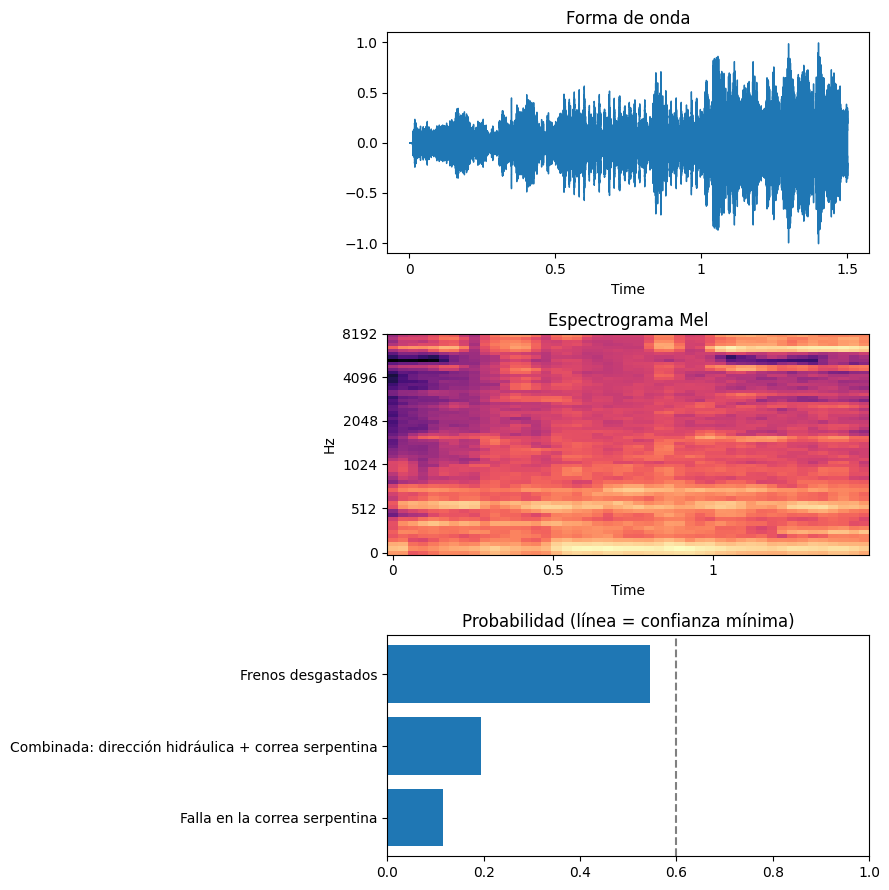

In [11]:
# 11. Prueba con tus propios audios: se abre un botón para subir uno o varios archivos
probar_subiendo()